In [ ]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))
from network import torus3D_manifold, visualize3D
from network.CAN3D import CAN3D, Kernel_BF


## 3-Dimensional Torus (T^3)
Since it is hard to visualize a 3D torus (it would need 4D) because a 3D scatter plot would cause outer neurons to block the view of inner neurons. Our approach is therefore to slice the 3D volumes into 2D slices. This means comparing two axes, for example theta_1 and theta_2 while fixing theta_3.

First, we create a manifold and visualize the distance metric over it. This is the distance between two points on the manifold amd it should show gradually increasing distance and be periodic.

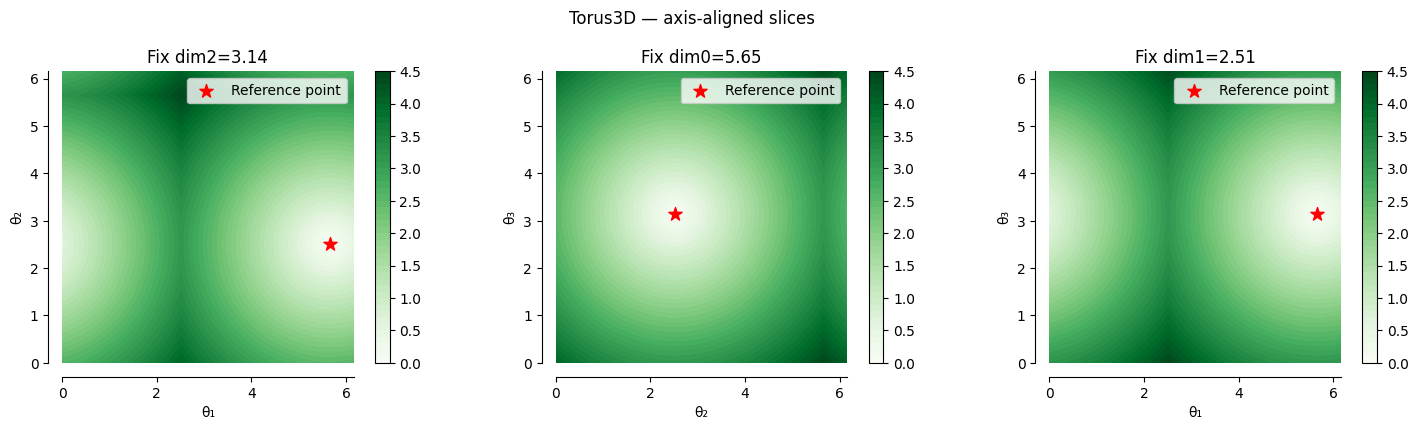

In [2]:
m = torus3D_manifold.Torus3D()

# sample points
points = m.parameter_space.sample(10)
#pick a random point from the torus
idx = np.random.randint(0, points.shape[0])
sample = points[idx, :]
assert m.contains(sample), "Sample point is not in the manifold"

fig, axes = visualize3D._visualize_manifold_3d(m, show_distances=True, distance_point=sample)

## CAN
Create the 3D CAN, activate a random neuron and visualize how this neuron exites the other neurons in the population. Showing if the connectivity matrix of each 4 randomly picked neurons is correct. 

finite-k Fourier peak = +2.539e+00  (>0 ⇒ a lattice can form)


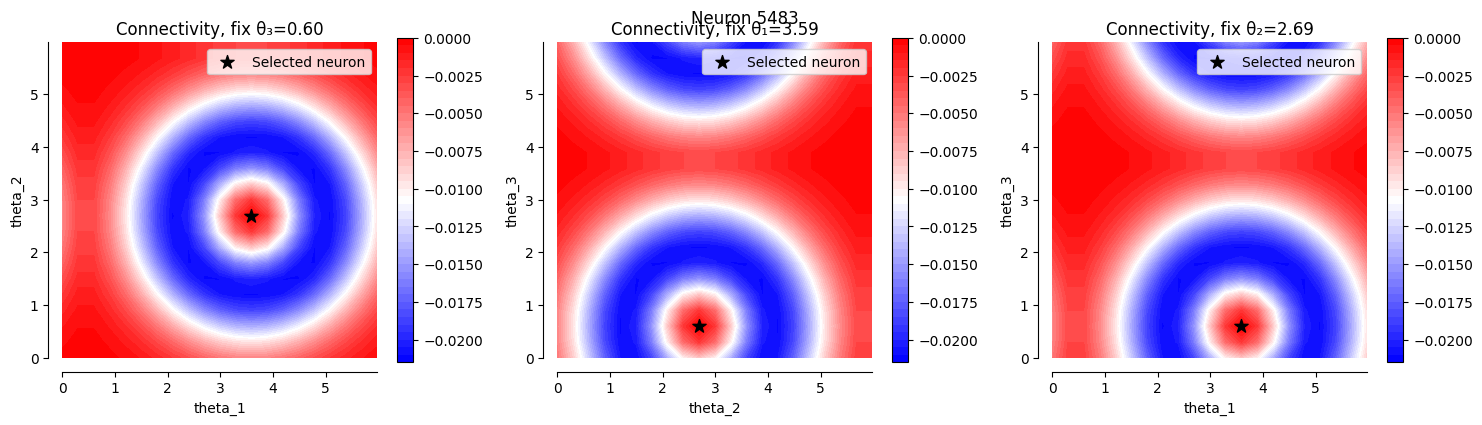

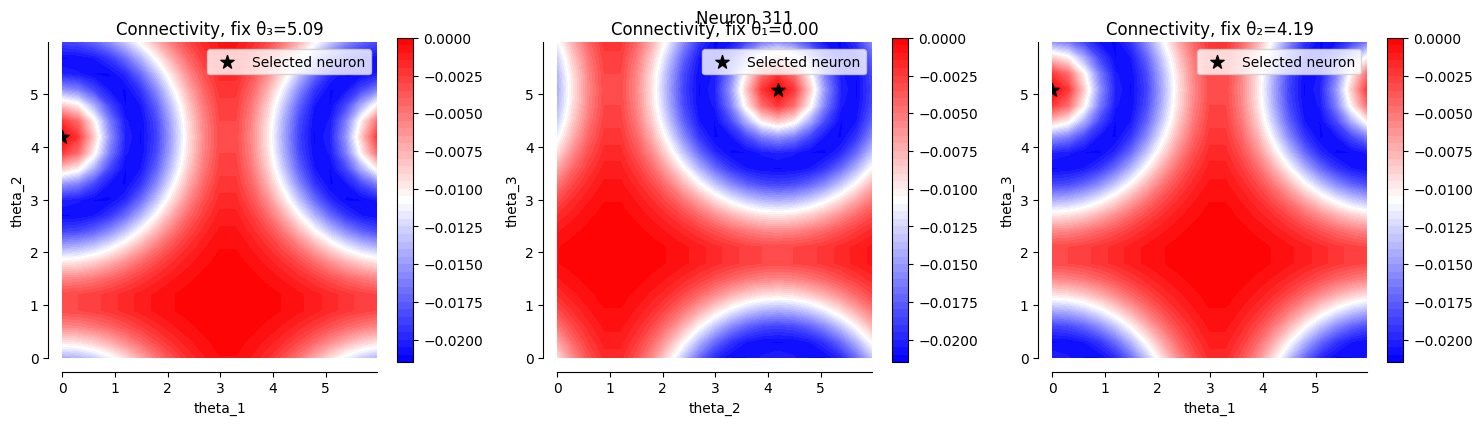

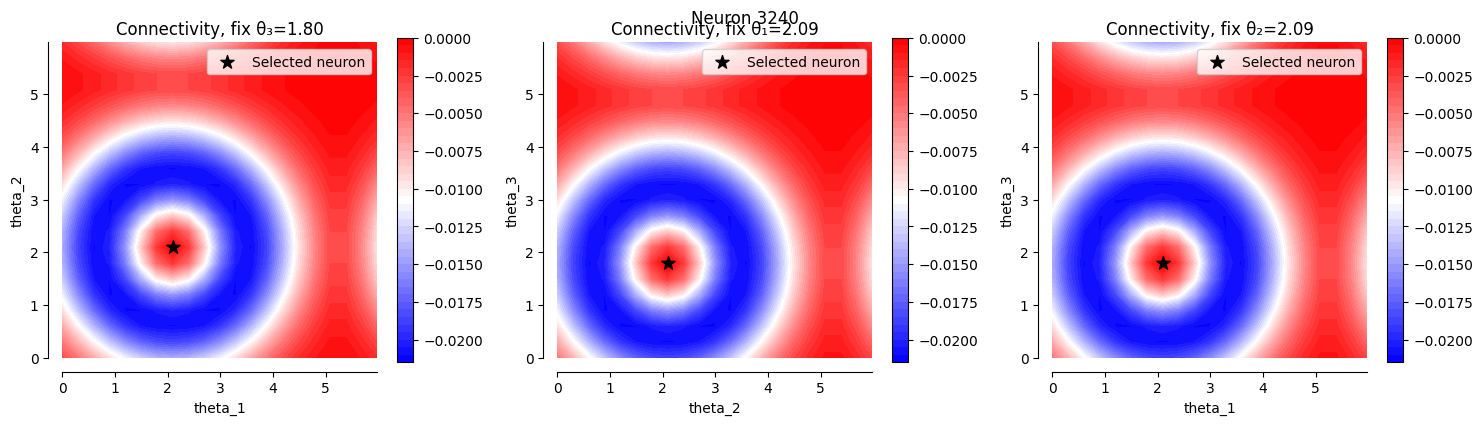

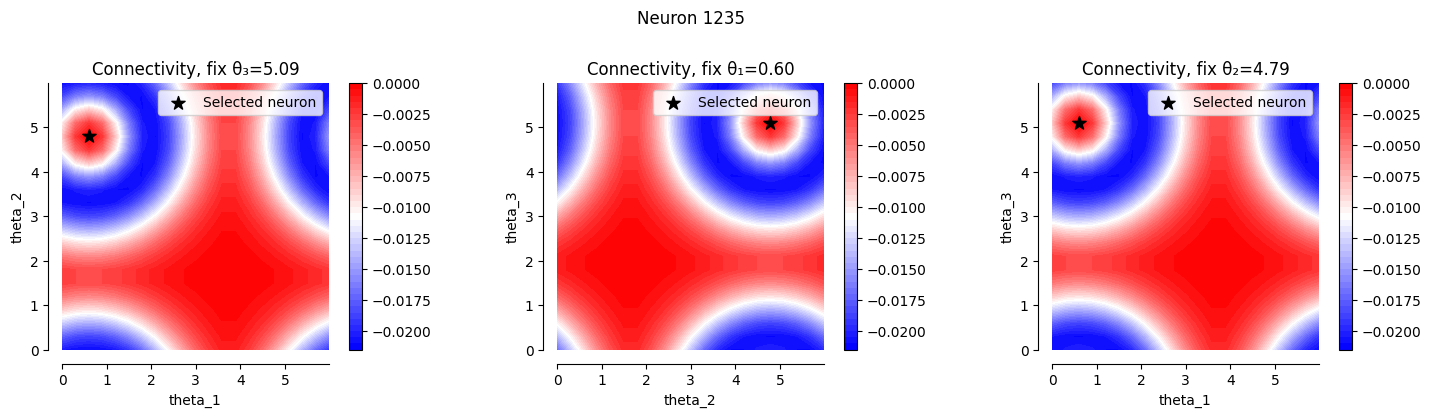

In [ ]:
SPACING        = 0.3
lambda_net     = 2.5    # larger period → ~8 neurons per field
ratio          = 1.05
target_margin  = 3.0    # push harder into unstable regime
B              = 0.3
sigma_i = lambda_net / np.sqrt(6.0)     # beta  = 3/lambda²
sigma_e = sigma_i / np.sqrt(ratio)      # gamma = 1.05·beta
kernel = Kernel_BF(lambda_net=2.5, ratio=1.05, a=1.0, gain=1.0)
peak, dc = finite_k_peak(kernel, m.metric, n)
kernel.gain = target_margin / peak


# inject the kernel
can_3d = CAN3D(m, spacing=SPACING, alpha=3.0, sigma=3.0,
               b=B, kernel=kernel, build_connectivity=True)

# auto-scaled colours so the centre-surround shows (the -1..0 default washes it out)
results = visualize3D.visualize_can_connectivity_3d(can_3d, vmin=None, vmax=None)
plt.show()

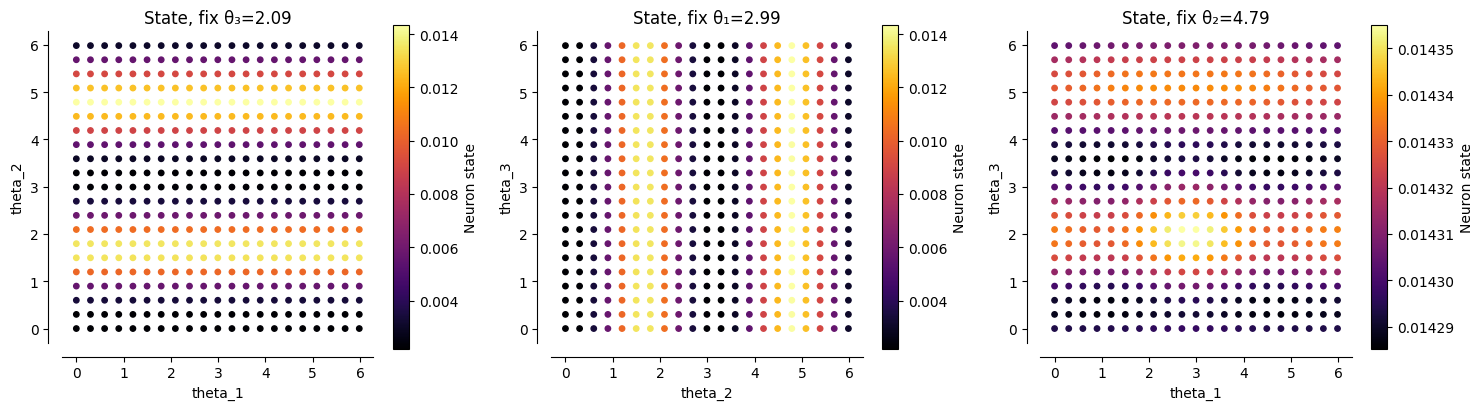

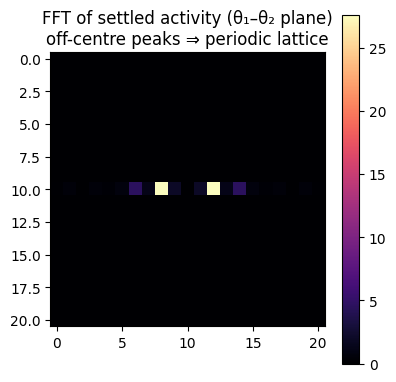

In [4]:
# Let the population self-organise from a random start (NOT a seeded point),
# so the unstable mode can grow into whatever pattern the kernel supports.
can_3d.reset(mode="random")
for _ in range(400):           # tau=5, so this is ~80 time-constants — plenty to settle
    can_3d()

# 1) the settled activity itself — several blobs per slice = a lattice
visualize3D.visualize_can_state_3d(can_3d)
plt.show()

# 2) Fourier confirmation: a periodic lattice shows bright peaks OFF the centre,
#    at |k| ≈ 2π/λ ≈ {:.1f} cycles. A blob only at the centre = no pattern (uniform).
n1, n2, n3 = can_3d.nx(0), can_3d.nx(1), can_3d.nx(2)
S3d = can_3d.S.reshape(n1, n2, n3)
P   = np.abs(np.fft.fftshift(np.fft.fftn(S3d - S3d.mean())))   # subtract mean to kill DC
plt.figure(figsize=(4, 4))
plt.imshow(P[:, :, n3 // 2], cmap="magma")
plt.title("FFT of settled activity (θ₁–θ₂ plane)\noff-centre peaks ⇒ periodic lattice")
plt.colorbar(); plt.tight_layout(); plt.show()

## Plot a CAN state
Show the acitivty levels of an randomly picked point and the activity levels of the neurons within a radius of that point. Checking two things, first, can we create a localised bump in a spesific random location. Secondly, will this broad bump converge into a smaller stable attractor state.